# Exjobb Latency Analysis

In [1]:
%pip install numpy matplotlib pandas

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Note: you may need to restart the kernel to use updated packages.


In [7]:
def get_trace_dataset(expid, runid):
    df = pd.read_csv(f'./traces/{expid}/{runid}/{runid}-trace.csv')
    return df


def get_experiment_info(expid):
    info = {}
    with open(f'./traces/{expid}/info.txt', 'r') as f:
        for i, line in enumerate(f):
            if i == 7:
                info['Dataplane'] = line.split(':')[1].strip()
            elif i == 8:
                info['Protocol'] = line.split(':')[1].strip()
            elif i == 9:
                info['Policy Direction'] = line.split(':')[1].strip()
            elif i == 10:
                info['Istio Installed'] = line.split(':')[1].strip()
            elif i == 11:
                info['Istio Policy'] = line.split(':')[1].strip()

    return info


def get_experiment_id(exp):
    return exp if isinstance(exp, str) else exp['id']


def get_run_ids(exp, default=('1', '2', '3')):
    if isinstance(exp, dict):
        return exp.get('runs', default)
    return default


def get_delay_key_for_experiment(expid):
    return 'delay' if get_experiment_info(expid)['Protocol'] == 'udp' else 'Delay (s)'


def get_combined_trace_dataset(expid, runids=('1', '2', '3')):
    frames = []
    for runid in runids:
        frames.append(get_trace_dataset(expid, runid).copy())
    return pd.concat(frames, ignore_index=True)


def get_clean_latency_series(df, delay_key='delay', protocol='udp'):
    latencies = df[delay_key]

    # HTTP requests always have a warm up time, remove the first three requests
    if protocol == 'http':
        latencies = latencies.iloc[3:]

    # Remove outliers using IQR method
    Q1 = latencies.quantile(0.25)
    Q3 = latencies.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = max(Q1 - 1.5 * IQR, 0)
    upper_bound = Q3 + 1.5 * IQR
    return latencies[(latencies >= lower_bound) & (latencies <= upper_bound)]


def get_combined_latency_series(exp, delay_key=None):
    expid = get_experiment_id(exp)
    info = get_experiment_info(expid)
    if delay_key is None:
        delay_key = get_delay_key_for_experiment(expid)

    df = get_combined_trace_dataset(expid, get_run_ids(exp))
    return get_clean_latency_series(df, delay_key=delay_key, protocol=info['Protocol'])


def bootstrap_mean_ci(latencies, n_resamples=2000, confidence=0.95, seed=42):
    values = latencies.to_numpy()
    if len(values) == 0:
        return (np.nan, np.nan)

    rng = np.random.default_rng(seed)
    bootstrap_means = rng.choice(values, size=(n_resamples, len(values)), replace=True).mean(axis=1)
    alpha = (1 - confidence) / 2
    return tuple(np.quantile(bootstrap_means, [alpha, 1 - alpha]))


def get_latency_statistics(latencies):
    q1 = latencies.quantile(0.25)
    q3 = latencies.quantile(0.75)
    iqr = q3 - q1
    ci_low, ci_high = bootstrap_mean_ci(latencies)

    return {
        'count': len(latencies),
        'mean': latencies.mean(),
        'median': latencies.median(),
        'std': latencies.std(ddof=1),
        'iqr': iqr,
        'p95': latencies.quantile(0.95),
        'p99': latencies.quantile(0.99),
        'mean_ci_low': ci_low,
        'mean_ci_high': ci_high,
    }


def percentage_change(base_value, new_value):
    return ((new_value - base_value) / base_value) * 100


def format_change(base_value, new_value):
    change = percentage_change(base_value, new_value)
    if change < 0:
        return f"{abs(change):.1f}% faster"
    return f"{change:.1f}% slower"


def summarize_latency_experiments(experiment_ids, delay_key=None):
    rows = []
    for expid in experiment_ids:
        latencies = get_combined_latency_series(expid, delay_key=delay_key)
        stats = get_latency_statistics(latencies)
        info = get_experiment_info(expid)
        rows.append({
            'Experiment': expid,
            'Dataplane': info['Dataplane'],
            'Protocol': info['Protocol'],
            'Policy Direction': info['Policy Direction'],
            'Istio Installed': info['Istio Installed'],
            'Istio Policy': info['Istio Policy'],
            **stats,
        })

    return pd.DataFrame(rows)


def print_latency_summary(experiment_ids, delay_key=None):
    summary = summarize_latency_experiments(experiment_ids, delay_key=delay_key)
    print(summary.to_string(index=False))
    return summary


def print_relative_latency_change(base_exp, compare_exp, label, delay_key=None):
    base_id = get_experiment_id(base_exp)
    compare_id = get_experiment_id(compare_exp)
    base_latencies = get_combined_latency_series(base_exp, delay_key=delay_key)
    compare_latencies = get_combined_latency_series(compare_exp, delay_key=delay_key)
    base_mean = base_latencies.mean()
    compare_mean = compare_latencies.mean()
    change = percentage_change(base_mean, compare_mean)
    if change < 0:
        print(
            f"{label}: {compare_id} is {abs(change):.1f}% faster than {base_id} "
            f"(mean {compare_mean:.6f} vs {base_mean:.6f})"
        )
    else:
        print(
            f"{label}: {compare_id} is {change:.1f}% slower than {base_id} "
            f"(mean {compare_mean:.6f} vs {base_mean:.6f})"
        )


def get_trace_dataset_and_plot(experimentstocompare, axs, index, delay_key='Delay (s)'):
    for exp in experimentstocompare:
        expid = get_experiment_id(exp)
        latencies = get_combined_latency_series(exp, delay_key=delay_key)
        stats = get_latency_statistics(latencies)

        print(
            f"{expid}: mean={stats['mean']:.6f}, median={stats['median']:.6f}, "
            f"std={stats['std']:.6f}, p95={stats['p95']:.6f}, p99={stats['p99']:.6f}"
        )

        sorted_lat = np.sort(latencies)
        p = np.linspace(0, 100, len(sorted_lat))

        axs[index].plot(p, sorted_lat, label=get_experiment_info(expid)['Policy Direction'])

    axs[index].set_xlabel('Percentile')
    if index == 0:
        axs[index].set_ylabel('Latency (s)')
    axs[index].set_title(f"{get_experiment_info(get_experiment_id(experimentstocompare[0]))['Dataplane']}")
    axs[index].grid(True)
    axs[index].legend()


def get_trace_dataset_and_plot_istio(experimentstocompare, axs, index, delay_key='Delay (s)'):
    for exp in experimentstocompare:
        expid = get_experiment_id(exp)
        latencies = get_combined_latency_series(exp, delay_key=delay_key)
        stats = get_latency_statistics(latencies)

        print(
            f"{expid}: mean={stats['mean']:.6f}, median={stats['median']:.6f}, "
            f"std={stats['std']:.6f}, p95={stats['p95']:.6f}, p99={stats['p99']:.6f}"
        )

        sorted_lat = np.sort(latencies)
        p = np.linspace(0, 100, len(sorted_lat))

        label = f"Istio: {get_experiment_info(expid)['Istio Installed'].capitalize()} - Policy: {get_experiment_info(expid)['Istio Policy']}"
        axs[index].plot(p, sorted_lat, label=label)

    axs[index].set_xlabel('Percentile')
    if index == 0:
        axs[index].set_ylabel('Latency (s)')
    axs[index].set_title(f"Istio - {get_experiment_info(get_experiment_id(experimentstocompare[0]))['Dataplane']}")
    axs[index].grid(True)
    axs[index].legend()


In [8]:
# Combined-run latency statistics for the experiments used below.
combined_run_experiments = [
    '40634', '40635', '40636', '40637',
    '40725', '40726', '40727', '40728',
    '40638', '40639', '40640', '40641',
    '40729', '40730', '40731', '40732',
    '40659', '40669', '40686', '40687',
    '40733', '40734', '40741', '40742',
]

latency_summary = summarize_latency_experiments(combined_run_experiments)
latency_summary = latency_summary.sort_values(['Protocol', 'Dataplane', 'Experiment']).reset_index(drop=True)
print(latency_summary.to_string(index=False))


Experiment Dataplane Protocol Policy Direction  Istio Installed Istio Policy  count     mean   median      std      iqr      p95      p99  mean_ci_low  mean_ci_high
     40729      ebpf     http             none               no        false   2994 0.000429 0.000448 0.000104 0.000181 0.000574 0.000597     0.000426      0.000433
     40730      ebpf     http          ingress               no        false   2994 0.000432 0.000448 0.000103 0.000176 0.000575 0.000594     0.000428      0.000436
     40731      ebpf     http           egress               no        false   2991 0.000429 0.000449 0.000104 0.000176 0.000573 0.000600     0.000426      0.000433
     40732      ebpf     http             both               no        false   2994 0.000430 0.000446 0.000103 0.000178 0.000572 0.000598     0.000426      0.000434
     40733      ebpf     http             none             with         true   2978 0.001010 0.001027 0.000116 0.000175 0.001185 0.001256     0.001006      0.001014
     40734

In [10]:
# Percentage comparisons phrased with explicit protocol and dataplane names.

def mean_latency(expid):
    return get_combined_latency_series(expid).mean()


def print_udp_dataplane_comparison(policy_label, iptables_expid, ebpf_expid):
    iptables_mean = mean_latency(iptables_expid)
    ebpf_mean = mean_latency(ebpf_expid)
    change = percentage_change(iptables_mean, ebpf_mean)

    if change < 0:
        print(
            f"UDP traffic ({policy_label}): using ebpf is {abs(change):.1f}% faster than iptables "
            f"(mean {ebpf_mean:.6f}s vs {iptables_mean:.6f}s)."
        )
    else:
        print(
            f"UDP traffic ({policy_label}): using ebpf is {change:.1f}% slower than iptables "
            f"(mean {ebpf_mean:.6f}s vs {iptables_mean:.6f}s)."
        )


def print_istio_overhead(dataplane, baseline_expid, istio_expid, scenario_label):
    baseline_mean = mean_latency(baseline_expid)
    istio_mean = mean_latency(istio_expid)
    change = percentage_change(baseline_mean, istio_mean)

    print(
        f"HTTP traffic ({dataplane}, {scenario_label}): with Istio latency increases by {change:.1f}% "
        f"compared with no Istio (mean {istio_mean:.6f}s vs {baseline_mean:.6f}s)."
    )


print('UDP dataplane comparison (combined runs):')
print_udp_dataplane_comparison('none', '40634', '40725')
print_udp_dataplane_comparison('ingress', '40635', '40726')
print_udp_dataplane_comparison('egress', '40636', '40727')
print_udp_dataplane_comparison('both', '40637', '40728')

print('\nIstio overhead compared with no-Istio baseline (combined runs):')
print_istio_overhead('iptables', '40638', '40659', 'with policy=false')
print_istio_overhead('iptables', '40638', '40669', 'with policy=true')
print_istio_overhead('iptables', '40638', '40687', 'with acceleration + policy=false')
print_istio_overhead('iptables', '40638', '40686', 'with acceleration + policy=true')
print_istio_overhead('ebpf', '40729', '40734', 'with policy=false')
print_istio_overhead('ebpf', '40729', '40733', 'with policy=true')
print_istio_overhead('ebpf', '40729', '40742', 'with acceleration + policy=false')
print_istio_overhead('ebpf', '40729', '40741', 'with acceleration + policy=true')


UDP dataplane comparison (combined runs):
UDP traffic (none): using ebpf is 6.0% faster than iptables (mean 0.000346s vs 0.000369s).
UDP traffic (ingress): using ebpf is 6.2% faster than iptables (mean 0.000345s vs 0.000368s).
UDP traffic (egress): using ebpf is 5.8% faster than iptables (mean 0.000347s vs 0.000369s).
UDP traffic (both): using ebpf is 6.0% faster than iptables (mean 0.000348s vs 0.000370s).

Istio overhead compared with no-Istio baseline (combined runs):
HTTP traffic (iptables, with policy=false): with Istio latency increases by 125.3% compared with no Istio (mean 0.001007s vs 0.000447s).
HTTP traffic (iptables, with policy=true): with Istio latency increases by 128.0% compared with no Istio (mean 0.001019s vs 0.000447s).
HTTP traffic (iptables, with acceleration + policy=false): with Istio latency increases by 128.7% compared with no Istio (mean 0.001022s vs 0.000447s).
HTTP traffic (iptables, with acceleration + policy=true): with Istio latency increases by 131.9% co

# UDP

Mean Latencies iptables, udp:
40634: mean=0.000369, median=0.000367, std=0.000112, p95=0.000546, p99=0.000589
40635: mean=0.000368, median=0.000366, std=0.000110, p95=0.000550, p99=0.000594
40636: mean=0.000369, median=0.000369, std=0.000112, p95=0.000548, p99=0.000589
40637: mean=0.000370, median=0.000368, std=0.000111, p95=0.000547, p99=0.000591

Mean Latencies ebpf, udp:
40725: mean=0.000346, median=0.000346, std=0.000105, p95=0.000507, p99=0.000543
40726: mean=0.000345, median=0.000347, std=0.000104, p95=0.000505, p99=0.000542
40727: mean=0.000347, median=0.000347, std=0.000105, p95=0.000509, p99=0.000552
40728: mean=0.000348, median=0.000348, std=0.000102, p95=0.000507, p99=0.000546


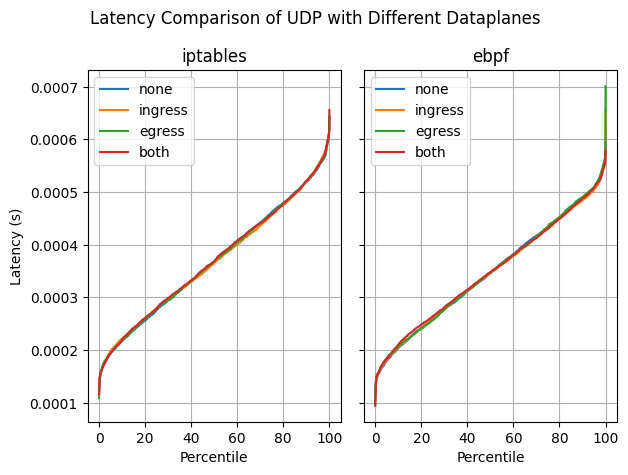

In [4]:
fig, axs = plt.subplots(1,2,sharey=True)
fig.suptitle('Latency Comparison of UDP with Different Dataplanes')

experimentstocompare = ['40634', '40635', '40636', '40637']
print(f"Mean Latencies {get_experiment_info(experimentstocompare[0])['Dataplane']}, {get_experiment_info(experimentstocompare[0])['Protocol']}:")
get_trace_dataset_and_plot(experimentstocompare, axs, index = 0, delay_key = "delay")

experimentstocompare = ['40725', '40726', '40727', '40728']
print(f"\nMean Latencies {get_experiment_info(experimentstocompare[0])['Dataplane']}, {get_experiment_info(experimentstocompare[0])['Protocol']}:")
get_trace_dataset_and_plot(experimentstocompare, axs, index = 1, delay_key = "delay")

plt.tight_layout()
plt.savefig('plots/latency_comparison_udp.pdf', format='pdf')
plt.show()

# HTTP

Mean Latencies iptables, http:
40638: mean=0.000447, median=0.000466, std=0.000104, p95=0.000592, p99=0.000617
40639: mean=0.000448, median=0.000465, std=0.000103, p95=0.000595, p99=0.000617
40640: mean=0.000447, median=0.000462, std=0.000104, p95=0.000592, p99=0.000619
40641: mean=0.000454, median=0.000475, std=0.000104, p95=0.000596, p99=0.000617
Mean Latencies ebpf, http:
40729: mean=0.000429, median=0.000448, std=0.000104, p95=0.000574, p99=0.000597
40730: mean=0.000432, median=0.000448, std=0.000103, p95=0.000575, p99=0.000594
40731: mean=0.000429, median=0.000449, std=0.000104, p95=0.000573, p99=0.000600
40732: mean=0.000430, median=0.000446, std=0.000103, p95=0.000572, p99=0.000598


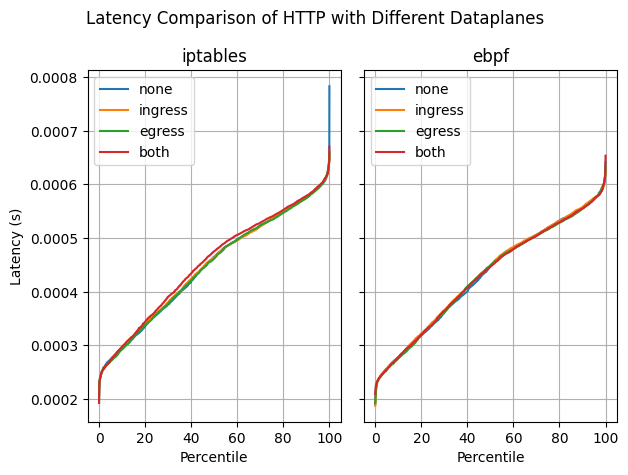

In [5]:
fig, axs = plt.subplots(1,2,sharey=True)
fig.suptitle('Latency Comparison of HTTP with Different Dataplanes')

experimentstocompare = ['40638', '40639', '40640', '40641']
print(f"Mean Latencies {get_experiment_info(experimentstocompare[0])['Dataplane']}, {get_experiment_info(experimentstocompare[0])['Protocol']}:")
get_trace_dataset_and_plot(experimentstocompare, axs, index = 0)

experimentstocompare = ['40729', '40730', '40731', '40732']
print(f"Mean Latencies {get_experiment_info(experimentstocompare[0])['Dataplane']}, {get_experiment_info(experimentstocompare[0])['Protocol']}:")
get_trace_dataset_and_plot(experimentstocompare, axs, index = 1)

plt.tight_layout()
plt.savefig('plots/latency_comparison_http.pdf', format='pdf')
plt.show()

## Istio

Mean Latencies Istio - iptables, http:
40638: mean=0.000447, median=0.000466, std=0.000104, p95=0.000592, p99=0.000617
40659: mean=0.001007, median=0.001019, std=0.000114, p95=0.001181, p99=0.001246
40669: mean=0.001019, median=0.001031, std=0.000112, p95=0.001188, p99=0.001250
40687: mean=0.001022, median=0.001033, std=0.000117, p95=0.001203, p99=0.001265
40686: mean=0.001036, median=0.001047, std=0.000115, p95=0.001217, p99=0.001284
Mean Latencies Istio - ebpf, http:
40729: mean=0.000429, median=0.000448, std=0.000104, p95=0.000574, p99=0.000597
40734: mean=0.000997, median=0.001010, std=0.000113, p95=0.001170, p99=0.001235
40733: mean=0.001010, median=0.001027, std=0.000116, p95=0.001185, p99=0.001256
40742: mean=0.001005, median=0.001015, std=0.000112, p95=0.001181, p99=0.001239
40741: mean=0.001018, median=0.001030, std=0.000116, p95=0.001195, p99=0.001261


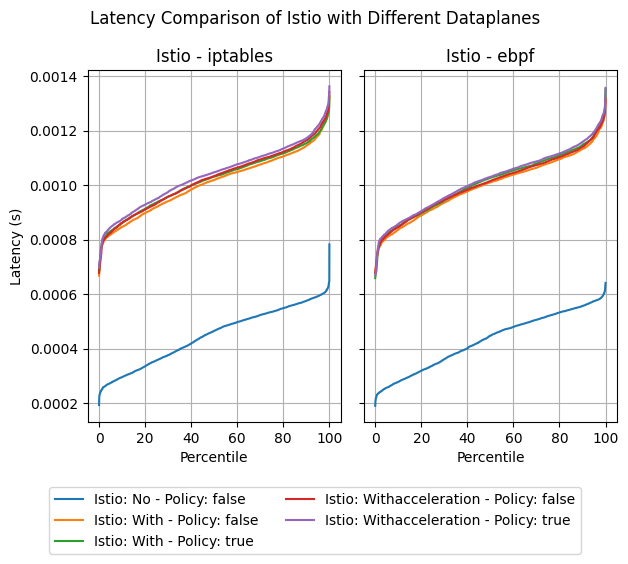

In [6]:
fig, axs = plt.subplots(1, 2,sharey=True)
fig.suptitle('Latency Comparison of Istio with Different Dataplanes')

experimentstocompare = ['40638', '40659', '40669', '40687', '40686']
print(f"Mean Latencies Istio - {get_experiment_info(experimentstocompare[0])['Dataplane']}, {get_experiment_info(experimentstocompare[0])['Protocol']}:")
get_trace_dataset_and_plot_istio(experimentstocompare, axs, index = 0)


experimentstocompare = ['40729', '40734', '40733', '40742', '40741']
print(f"Mean Latencies Istio - {get_experiment_info(experimentstocompare[0])['Dataplane']}, {get_experiment_info(experimentstocompare[0])['Protocol']}:")
get_trace_dataset_and_plot_istio(experimentstocompare, axs, index = 1)

fig.legend(axs[0].get_legend_handles_labels()[0], axs[0].get_legend_handles_labels()[1], loc='upper center', bbox_to_anchor=(0.5, 0), ncol=2)
axs[0].get_legend().remove()  # Remove legend from the first subplot
axs[1].get_legend().remove()  # Remove legend from the second subplot
plt.tight_layout()
plt.savefig('plots/latency_comparison_istio.pdf', format='pdf', bbox_inches='tight')
plt.show()